In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.7 MB/s eta 0:00:00


In [5]:
!pip install roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [7]:
from ultralytics import YOLO
from roboflow import Roboflow
import os


In [8]:


from roboflow import Roboflow
rf = Roboflow(api_key="yUg3vkHtUQPvGCrcCRRx")
project = rf.workspace("abdzah").project("autism-detect")
version = project.version(2)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to autism-detect-2 in yolov12:: 100%|██████████| 1055/1055 [00:00<00:00, 9024.88it/s]


In [ ]:
dataset.location


'/content/autism-detect-2'

In [ ]:
!ls {dataset.location}


data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [ ]:
!cat {dataset.location}/data.yaml


cat: {dataset.location}/data.yaml: No such file or directory


In [9]:
model = YOLO("yolo11n.pt")


In [ ]:
model.train(
    data=f"/content/autism-detect-2/data.yaml",
    epochs=25,
    imgsz=640,
    batch=8,
    patience=5,
    cos_lr=True,
    project="/content/drive/MyDrive/YOLO_Autism",
    name="exp_v2",
    device=0
)



Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/autism-detect-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e4ac4411e20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!ls /content/drive/MyDrive/YOLO_Autism/exp_v2/weights


best.pt  last.pt


In [10]:
model = YOLO("/content/drive/MyDrive/YOLO_Autism/exp_v2/weights/best.pt")


In [11]:
import pandas as pd

results = pd.read_csv("/content/drive/MyDrive/YOLO_Autism/exp_v2/results.csv")
final_recall = results["metrics/recall(B)"].iloc[-1]

print("Final Recall:", final_recall)



Final Recall: 0.67802


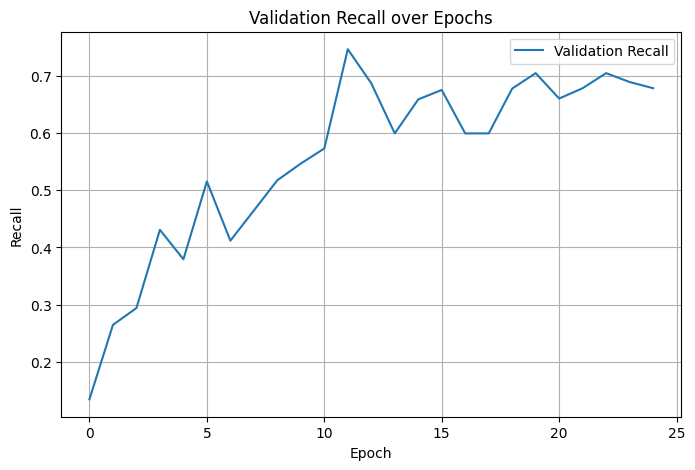

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/drive/MyDrive/YOLO_Autism/exp_v2/results.csv")

plt.figure(figsize=(8,5))
plt.plot(results["metrics/recall(B)"], label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Validation Recall over Epochs")
plt.legend()
plt.grid(True)
plt.show()


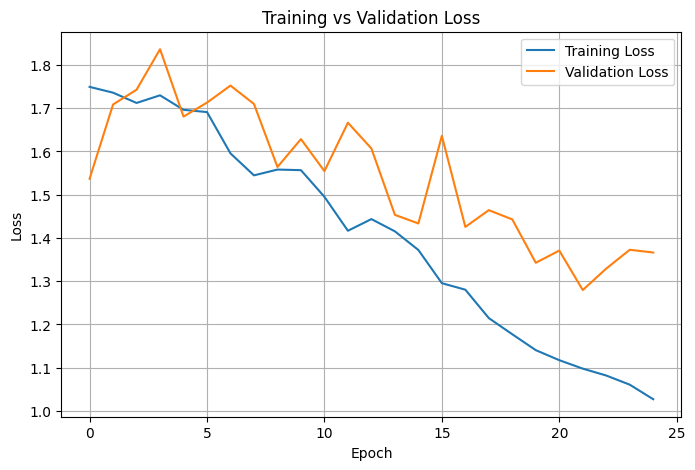

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/drive/MyDrive/YOLO_Autism/exp_v2/results.csv")

plt.figure(figsize=(8,5))
plt.plot(results["train/box_loss"], label="Training Loss")
plt.plot(results["val/box_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install gradio


In [12]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Autism/exp_v2/weights/best.pt")


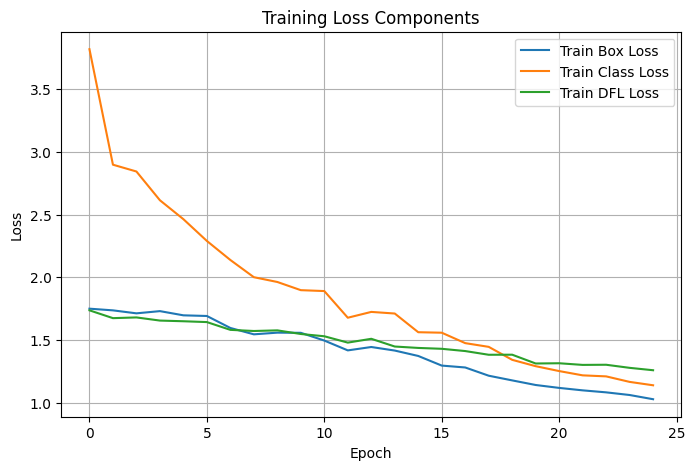

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = "/content/drive/MyDrive/YOLO_Autism/exp_v2/results.csv"
df = pd.read_csv(results_path)

plt.figure(figsize=(8, 5))
plt.plot(df["train/box_loss"], label="Train Box Loss")
plt.plot(df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["train/dfl_loss"], label="Train DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Components")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

def predict_image(image):
    results = model.predict(
        source=image,
        conf=0.1
    )
    annotated_image = results[0].plot()
    return annotated_image


In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Image(type="numpy", label="Detection Result"),
    title="Autism Behavior Detection",
    description="Upload an image to detect autism-related behaviors using YOLO"
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2c0aefda835220a65f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!ls /content/drive/MyDrive/YOLO_Autism/exp_v2/weights


best.pt  last.pt


In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)


Saving download.jpg to download.jpg
Uploaded image: download.jpg



image 1/1 /content/download.jpg: 480x640 1 ArmFlapping, 56.5ms
Speed: 3.3ms preprocess, 56.5ms inference, 35.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


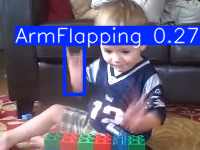

In [ ]:
results = model.predict(
    source=image_path,
    conf=0.1,
    save=True
)

results[0].show()


In [ ]:
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Uploaded video:", video_path)


Saving Head bangin.mp4 to Head bangin.mp4
Uploaded video: Head bangin.mp4


In [ ]:
results = model.predict(
    source=video_path,
    conf=0.15,
    save=True
)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1603) /content/Head bangin.mp4: 640x384 (no detections), 90.5ms
video 1/1 (frame 2/1603) /content/Head bangin.mp4: 640x384 (no detections), 9.8ms
video 1/1 (frame 3/1603) /content/Head bangin.mp4: 640x384 (no detections), 8.2ms
video 1/1 (frame 4/1603) /content/Head bangin.mp4: 640x384 (no detections), 9.5ms
video 1/1 (frame 5/1603) /content/Head bangin.mp4: 640x384 (no detections), 8.4ms
video 1/1 (frame 6/1603) /content/Head bangin.m

In [ ]:
!ls runs/detect


predict
